# Notebook 5 - Geospatial Analysis — Glacier Elevation Change (Revised)

**v2 — Reviewer response:**
- Raster paths updated to new pipeline: `differenced_dems/`
- Epochs: SRTM−IGM (1954–2000), UAV−IGM (1954–2024), Pléiades−IGM
  (1954–2025), ASTER−SRTM (2000–2018), UAV−SRTM (2000–2024),
  Pléiades−SRTM (2000–2025), UAV−ASTER (2018–2024),
  Pléiades−ASTER (2018–2025). Note: ASTER 2008 excluded after
  quality filtering due to residual snow bias.
- Spearman rank correlation (primary) + Pearson reported for all
  topographic correlations (aspect, slope, elevation) per RC1
- Global Moran's I and Local Moran's I (LISA) spatial autocorrelation
  analysis added for all epochs
- Area change vs elevation change per glacier scatter plot added per RC1
- Hypsometric dH analysis retained
- Outline sensitivity analysis updated to reflect time-weighted mean
  area approach: 1975/2000 areas for 1954-based epochs, 2000/2019
  areas for 2000-based epochs, following Cogley et al. (2011)
- dh map figures split into Fig 3 (1954-based) and Fig 4 (2000-based),
  2×2 layout each


## Cell 1 — Imports

In [5]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.transform import xy
from shapely.geometry import mapping
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
import contextily as ctx
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from esda.moran import Moran, Moran_Local
from libpysal.weights import lat2W
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        12,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})


## Cell 2 — User settings: all paths and epoch definitions

In [6]:
# Working directory
WORK_DIR   = '/Users/milliespencer/Glacier-DEM-coregistration-and-MB'
DH_DIR     = os.path.join(WORK_DIR, 'differenced_dems')   # new pipeline outputs
FIGURES    = os.path.join(WORK_DIR, 'figures')
RESULTS    = os.path.join(WORK_DIR, 'results')
os.makedirs(FIGURES, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

# SRTM reference DEM (for slope/aspect/elevation extraction)
SRTM_PATH  = os.path.join(WORK_DIR, 'coreg_dems_demcoreg', 'SRTM_2000_coreg.tif')

# Glacier shapefiles
SHP = {
    '1975': '/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp',
    '2000': os.path.join(WORK_DIR, 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp'),
    '2019': os.path.join(WORK_DIR, 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp'),
}

# Subcomplex glacier ID lists (from Notebook 3)
CERRO_BLANCO_GLACIERS = [
    'CL108101050','CL108105002','CL108101048','CL108116003','CL108116002',
    'CL108116001','CL108116005','CL108116006','CL108116004','CL108101049','CL108105003'
]
LASTERMAS_GLACIERS = [
    'CL108130010','CL108100003','CL108100002','CL108100004','CL108130008',
    'CL108130003','CL108130007','CL108130006','CL108130005','CL108130004',
    'CL108100005','CL108100006','CL108101047','CL108101046','CL108130009'
]
SADDLE_GLACIERS  = ['CL108130002','CL108130001']
GLACIAR_NEVADO   = 'CL108116004'

# ==============================================================================
# Epoch definitions
# Each entry: (label, dh_tif, clip_shapefile_key, t_start, t_end, subcomplex)
# clip_shapefile_key refers to the SHP dict above
# ==============================================================================
EPOCHS = [
    # Whole complex / IGM baseline
    ('SRTM−IGM 1954–2000',        'SRTM_2000_minus_IGM_1954_dh.tif',        '1975', 1954, 2000, 'whole'),
    ('Pléiades−IGM 1954–2025',    'Pleiades_2025_minus_IGM_1954_dh.tif',    '1975', 1954, 2025, 'whole'),
    # SRTM-based — whole complex
    ('Pléiades−SRTM 2000–2025',   'Pleiades_2025_minus_SRTM_2000_dh.tif',   '2000', 2000, 2025, 'whole'),
    ('ASTER 2008−SRTM 2000–2008', 'ASTER_20080330_minus_SRTM_2000_dh.tif',  '2000', 2000, 2008, 'whole'),
    ('ASTER 2018−SRTM 2000–2018', 'ASTER_20180301_minus_SRTM_2000_dh.tif',  '2000', 2000, 2018, 'whole'),
    # UAV subcomplexes
    ('CB UAV−IGM 1954–2024',      'CerroBlanco_2024_minus_IGM_1954_dh.tif', '1975', 1954, 2024, 'cerro_blanco'),
    ('CB UAV−SRTM 2000–2024',     'CerroBlanco_2024_minus_SRTM_2000_dh.tif','2000', 2000, 2024, 'cerro_blanco'),
    ('LT UAV−IGM 1954–2024',      'LasTermas_2024_minus_IGM_1954_dh.tif',   '1975', 1954, 2024, 'las_termas'),
    ('LT UAV−SRTM 2000–2024',     'LasTermas_2024_minus_SRTM_2000_dh.tif',  '2000', 2000, 2024, 'las_termas'),
]

SUBCOMPLEX_IDS = {
    'whole':        CERRO_BLANCO_GLACIERS + LASTERMAS_GLACIERS + SADDLE_GLACIERS,
    'cerro_blanco': CERRO_BLANCO_GLACIERS,
    'las_termas':   LASTERMAS_GLACIERS,
}

SUBCOMPLEX_COLORS = {
    'whole':        '#4878CF',
    'cerro_blanco': '#D65F5F',
    'las_termas':   '#6ACC65',
}


## Cell 3 — Helper functions

In [3]:
def load_outlines(year_key):
    """Load glacier outlines for a given inventory year."""
    gdf = gpd.read_file(SHP[year_key]).to_crs('EPSG:32719')
    if year_key == '1975':
        gdf['COD_GLA'] = gdf.index.astype(str) + '_1975'
    else:
        gdf['COD_GLA'] = gdf['COD_GLA'].str.rstrip('@')
    return gdf.dropna(subset=['geometry'])


def extract_pixels(dh_path, outlines_gdf):
    """Extract valid dH pixels within glacier outlines. Returns flat array."""
    if not os.path.exists(dh_path):
        return np.array([])
    valid = outlines_gdf[outlines_gdf.geometry.notna() & ~outlines_gdf.geometry.is_empty]
    if len(valid) == 0:
        return np.array([])
    try:
        with rasterio.open(dh_path) as src:
            proj = valid.to_crs(src.crs)
            geoms = [mapping(g) for g in proj.geometry]
            arr, _ = mask(src, geoms, crop=True, nodata=np.nan, filled=True)
            arr = arr[0].astype(float)
            arr[arr == src.nodata] = np.nan
            arr[np.abs(arr) > 200] = np.nan   # sanity filter
            return arr[np.isfinite(arr)].flatten()
    except Exception as e:
        print(f'  extract_pixels failed for {os.path.basename(dh_path)}: {e}')
        return np.array([])


def extract_pixels_per_glacier(dh_path, outlines_gdf, cod_col='COD_GLA'):
    """Extract mean dH per glacier polygon. Returns DataFrame."""
    rows = []
    if not os.path.exists(dh_path):
        return pd.DataFrame()
    with rasterio.open(dh_path) as src:
        for _, row in outlines_gdf.iterrows():
            if row.geometry is None or row.geometry.is_empty:
                continue
            try:
                proj_geom = gpd.GeoSeries([row.geometry], crs=outlines_gdf.crs).to_crs(src.crs)
                arr, _ = mask(src, [mapping(proj_geom.iloc[0])], crop=True,
                              nodata=np.nan, filled=True)
                arr = arr[0].astype(float)
                arr[arr == src.nodata] = np.nan
                arr[np.abs(arr) > 200] = np.nan
                vals = arr[np.isfinite(arr)]
                if len(vals) > 0:
                    rows.append({
                        'COD_GLA':   row[cod_col],
                        'dh_mean_m': np.nanmean(vals),
                        'dh_median_m': np.nanmedian(vals),
                        'n_pixels':  len(vals),
                        'area_m2':   row.geometry.area,
                    })
            except Exception:
                continue
    return pd.DataFrame(rows)


def compute_slope_aspect_elevation(dem_path):
    """Compute slope, aspect, and elevation arrays from a DEM."""
    with rasterio.open(dem_path) as src:
        dem = src.read(1).astype(float)
        dem[dem == src.nodata] = np.nan
        dem[dem < 0] = np.nan
        dem[dem > 7000] = np.nan
        t = src.transform
        xres = abs(t.a)
        yres = abs(t.e)
    dy, dx = np.gradient(dem, yres, xres)
    slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
    aspect = np.degrees(np.arctan2(-dx, dy))
    aspect = np.where(aspect < 0, 360 + aspect, aspect)
    return dem, slope, aspect


def correlation_stats(x, y):
    """Pearson and Spearman r, r², p-value. Returns dict."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 5:
        return {}
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    return {
        'n':          len(x),
        'pearson_r':  pr,  'pearson_r2':  pr**2,  'pearson_p':  pp,
        'spearman_r': sr,  'spearman_r2': sr**2,  'spearman_p': sp,
    }


## Cell 4 — Step 1: Glacier-level correlation — dH vs topographic attributes

In [4]:
print('='*70)
print('STEP 1: Glacier-level dH vs topographic attributes')
print('Pearson + Spearman (Spearman primary — robust to non-normal distributions)')
print('='*70)

all_results = []

for label, dh_file, shp_key, t_start, t_end, subcomplex in EPOCHS:
    dh_path = os.path.join(DH_DIR, dh_file)
    if not os.path.exists(dh_path):
        print(f'  SKIP (not found): {dh_file}')
        continue

    outlines = load_outlines(shp_key)
    if shp_key != '1975':
        ids = SUBCOMPLEX_IDS.get(subcomplex, SUBCOMPLEX_IDS['whole'])
        outlines = outlines[outlines['COD_GLA'].isin(ids)]

    df_gla = extract_pixels_per_glacier(dh_path, outlines)
    if df_gla.empty:
        print(f'  SKIP (no pixels): {label}')
        continue

    # Extract per-glacier elevation, slope, aspect from SRTM
    terrain_rows = []
    with rasterio.open(SRTM_PATH) as srtm_src:
        srtm_data = srtm_src.read(1).astype(float)
        srtm_data[srtm_data == srtm_src.nodata] = np.nan
        t = srtm_src.transform
        dy_full, dx_full = np.gradient(
            np.nan_to_num(srtm_data, nan=0),
            abs(t.e), abs(t.a))
        slope_full  = np.degrees(np.arctan(np.sqrt(dx_full**2 + dy_full**2)))
        aspect_full = np.degrees(np.arctan2(-dx_full, dy_full))
        aspect_full = np.where(aspect_full < 0, 360 + aspect_full, aspect_full)

        for _, row in outlines.iterrows():
            if row.geometry is None or row.geometry.is_empty:
                continue
            try:
                proj_geom = gpd.GeoSeries(
                    [row.geometry], crs=outlines.crs).to_crs(srtm_src.crs)
                arr, tfm = mask(
                    srtm_src, [mapping(proj_geom.iloc[0])],
                    crop=True, nodata=np.nan, filled=True)
                elev_vals = arr[0].astype(float)
                elev_vals[elev_vals == srtm_src.nodata] = np.nan

                # Slice slope/aspect to same window
                bounds = proj_geom.total_bounds
                win = rasterio.windows.from_bounds(
                    bounds[0], bounds[1], bounds[2], bounds[3],
                    transform=srtm_src.transform)
                r0 = max(0, int(win.row_off))
                r1 = min(srtm_data.shape[0], int(win.row_off + win.height) + 1)
                c0 = max(0, int(win.col_off))
                c1 = min(srtm_data.shape[1], int(win.col_off + win.width)  + 1)

                terrain_rows.append({
                    'COD_GLA':     row['COD_GLA'],
                    'elev_mean_m': float(np.nanmean(elev_vals)),
                    'slope_mean':  float(np.nanmean(slope_full[r0:r1, c0:c1])),
                    'aspect_mean': float(np.nanmean(aspect_full[r0:r1, c0:c1])),
                })
            except Exception:
                continue

    df_terrain = pd.DataFrame(terrain_rows)
    df_merged  = df_gla.merge(df_terrain, on='COD_GLA', how='inner')
    if len(df_merged) < 5:
        print(f'  SKIP (<5 glaciers): {label}')
        continue

    print(f'\n{label} (n={len(df_merged)} glaciers)')
    for topo_var, topo_label in [
        ('elev_mean_m', 'Mean elevation (m)'),
        ('slope_mean',  'Mean slope (°)'),
        ('aspect_mean', 'Mean aspect (°)'),
    ]:
        stats_d = correlation_stats(
            df_merged[topo_var].values,
            df_merged['dh_mean_m'].values)
        if not stats_d:
            continue
        sig_s = '✓' if stats_d['spearman_p'] < 0.05 else 'ns'
        sig_p = '✓' if stats_d['pearson_p']  < 0.05 else 'ns'
        print(f'  dH vs {topo_label:<25} '
              f'Spearman ρ={stats_d["spearman_r"]:+.2f} r²={stats_d["spearman_r2"]:.2f} '
              f'p={stats_d["spearman_p"]:.3f} {sig_s} | '
              f'Pearson r={stats_d["pearson_r"]:+.2f} p={stats_d["pearson_p"]:.3f} {sig_p}')
        all_results.append({
            'epoch': label, 't_start': t_start, 't_end': t_end,
            'subcomplex': subcomplex, 'topo_var': topo_var,
            'n_glaciers': stats_d['n'],
            **{k: v for k, v in stats_d.items()},
        })

df_corr = pd.DataFrame(all_results)
df_corr.to_csv(os.path.join(RESULTS, 'topo_correlation_results.csv'), index=False)
print(f'\nSaved: {RESULTS}/topo_correlation_results.csv')

STEP 1: Glacier-level dH vs topographic attributes
Pearson + Spearman (Spearman primary — robust to non-normal distributions)

SRTM−IGM 1954–2000 (n=7 glaciers)
  dH vs Mean elevation (m)        Spearman ρ=+0.39 r²=0.15 p=0.383 ns | Pearson r=+0.50 p=0.250 ns
  dH vs Mean slope (°)            Spearman ρ=+0.68 r²=0.46 p=0.094 ns | Pearson r=+0.70 p=0.079 ns
  dH vs Mean aspect (°)           Spearman ρ=-0.46 r²=0.22 p=0.294 ns | Pearson r=-0.50 p=0.255 ns

Pléiades−IGM 1954–2025 (n=7 glaciers)
  dH vs Mean elevation (m)        Spearman ρ=+0.43 r²=0.18 p=0.337 ns | Pearson r=+0.52 p=0.227 ns
  dH vs Mean slope (°)            Spearman ρ=+0.64 r²=0.41 p=0.119 ns | Pearson r=+0.66 p=0.105 ns
  dH vs Mean aspect (°)           Spearman ρ=-0.43 r²=0.18 p=0.337 ns | Pearson r=-0.49 p=0.259 ns

Pléiades−SRTM 2000–2025 (n=28 glaciers)
  dH vs Mean elevation (m)        Spearman ρ=-0.36 r²=0.13 p=0.059 ns | Pearson r=-0.29 p=0.136 ns
  dH vs Mean slope (°)            Spearman ρ=+0.06 r²=0.00 p=0.757

## Cell 5 — Step 1b: Area change vs elevation change per glacier


STEP 1b: Area change vs mass balance per glacier (2000→2019, Pléiades)
n = 20 glaciers
Spearman ρ = -0.018  r² = 0.000  p = 0.9398
Pearson  r = -0.075  r² = 0.006  p = 0.7529


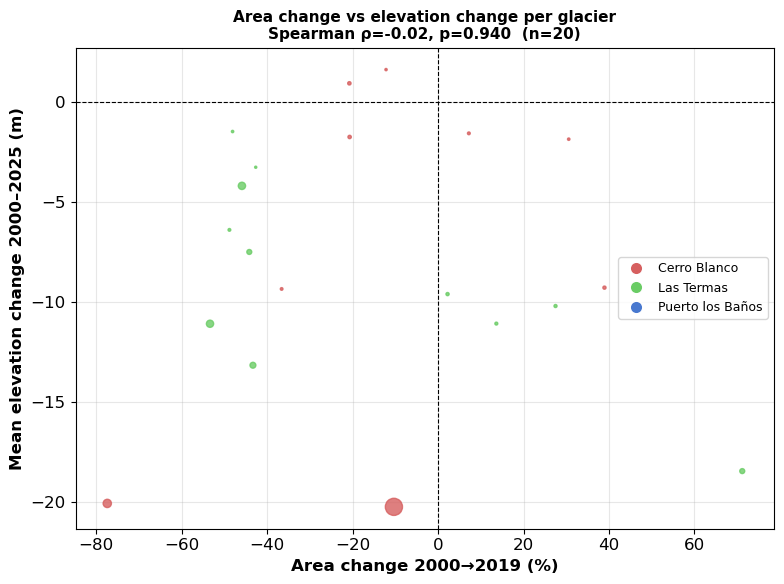

Saved: figures/area_change_vs_dh_glacier.png


In [5]:
# =============================================================================
print('\n' + '='*70)
print('STEP 1b: Area change vs mass balance per glacier (2000→2019, Pléiades)')
print('='*70)

gdf_2000 = load_outlines('2000')
gdf_2019 = load_outlines('2019')

dh_plei = os.path.join(DH_DIR, 'Pleiades_2025_minus_SRTM_2000_dh.tif')
df_plei = extract_pixels_per_glacier(
    dh_plei,
    gdf_2000[gdf_2000['COD_GLA'].isin(SUBCOMPLEX_IDS['whole'])],
)

area_2019 = gdf_2019.set_index('COD_GLA')['geometry'].apply(lambda g: g.area)
df_plei['area_2019_m2'] = df_plei['COD_GLA'].map(area_2019)
df_plei['area_change_pct'] = (df_plei['area_2019_m2'] / df_plei['area_m2'] - 1) * 100
df_plei['subcomplex'] = df_plei['COD_GLA'].map(
    {**{k: 'Cerro Blanco' for k in CERRO_BLANCO_GLACIERS},
     **{k: 'Las Termas'   for k in LASTERMAS_GLACIERS},
     **{k: 'Puerto los Baños' for k in SADDLE_GLACIERS}})

df_valid = df_plei.dropna(subset=['area_change_pct', 'dh_mean_m'])

stats_area = correlation_stats(
    df_valid['area_change_pct'].values,
    df_valid['dh_mean_m'].values)

print(f'n = {len(df_valid)} glaciers')
print(f'Spearman ρ = {stats_area["spearman_r"]:+.3f}  '
      f'r² = {stats_area["spearman_r2"]:.3f}  '
      f'p = {stats_area["spearman_p"]:.4f}')
print(f'Pearson  r = {stats_area["pearson_r"]:+.3f}  '
      f'r² = {stats_area["pearson_r2"]:.3f}  '
      f'p = {stats_area["pearson_p"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
colors_sub = {'Cerro Blanco': '#D65F5F', 'Las Termas': '#6ACC65',
              'Puerto los Baños': '#4878CF'}
for sub, grp in df_valid.groupby('subcomplex'):
    ax.scatter(grp['area_change_pct'], grp['dh_mean_m'],
               color=colors_sub.get(sub, 'grey'),
               s=grp['area_m2']/5000, alpha=0.8, label=sub, zorder=3)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Area change 2000→2019 (%)')
ax.set_ylabel('Mean elevation change 2000–2025 (m)')
ax.set_title(f'Area change vs elevation change per glacier\n'
             f'Spearman ρ={stats_area["spearman_r"]:+.2f}, '
             f'p={stats_area["spearman_p"]:.3f}  (n={len(df_valid)})',
             fontsize=11)

# RC1 Fig.4: legend as Line2D not Patch
legend_handles = [
    mlines.Line2D([], [], marker='o', color='w',
                  markerfacecolor=colors_sub[s],
                  markersize=9, label=s)
    for s in colors_sub
]
ax.legend(handles=legend_handles, fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES, 'area_change_vs_dh_glacier.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: figures/area_change_vs_dh_glacier.png')


## Cell 6 — Step 2: Pixel-level dH statistics and distributions


STEP 2: Pixel-level dH distributions per epoch


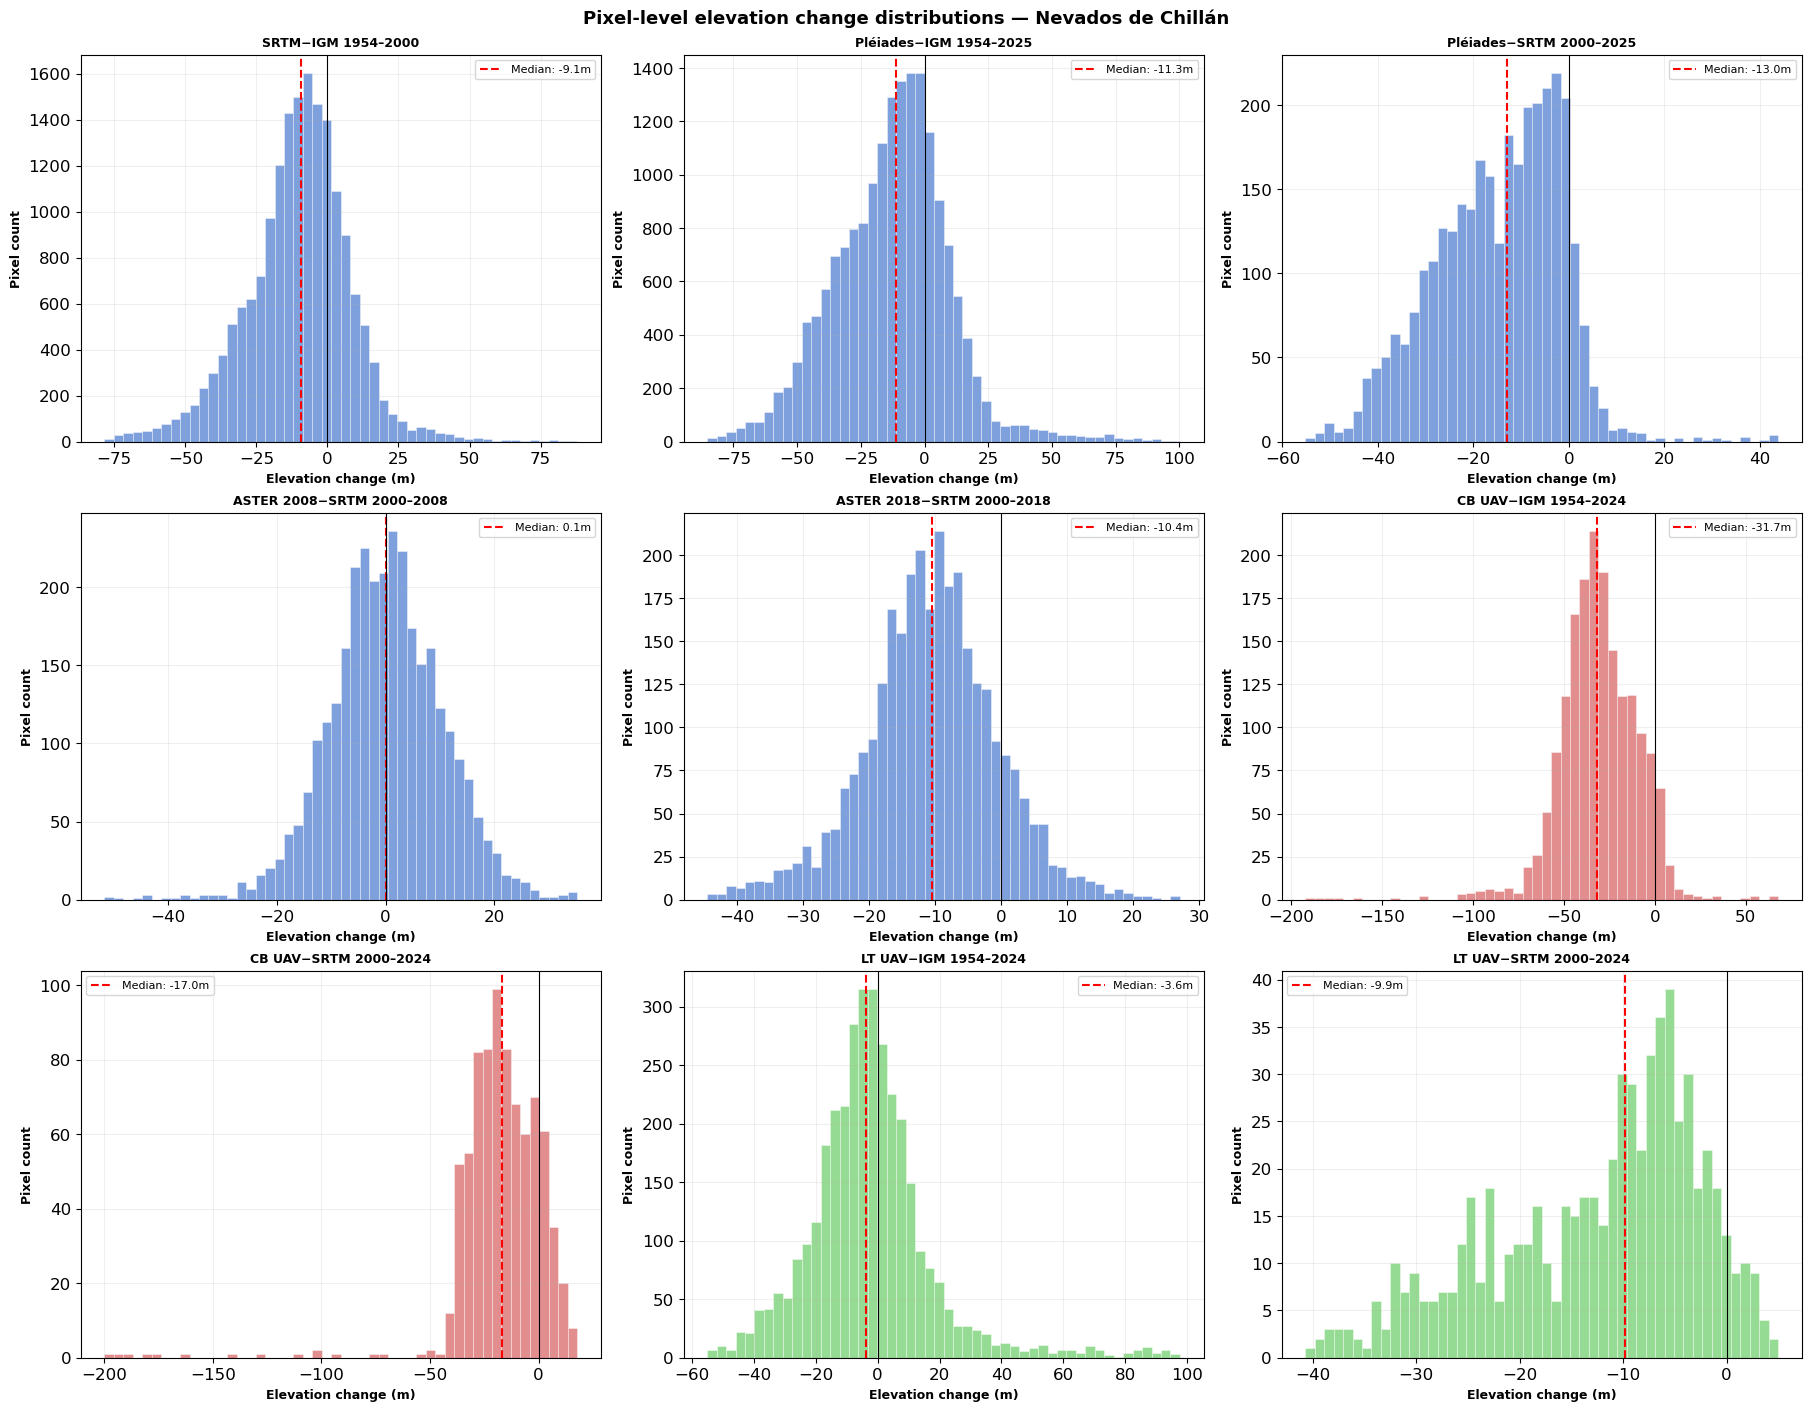

                    epoch  t_start  t_end  dt_yr   subcomplex  n_pixels  mean_dh_m  median_dh_m  std_dh_m  mean_rate_m_yr  median_rate_m_yr
       SRTM−IGM 1954–2000     1954   2000     46        whole     17805    -10.306       -9.135    18.502         -0.2240           -0.1986
   Pléiades−IGM 1954–2025     1954   2025     71        whole     17800    -12.874      -11.340    22.726         -0.1813           -0.1597
  Pléiades−SRTM 2000–2025     2000   2025     25        whole      3230    -14.784      -13.013    13.195         -0.5914           -0.5205
ASTER 2008−SRTM 2000–2008     2000   2008      8        whole      3139      0.058        0.107    10.425          0.0072            0.0134
ASTER 2018−SRTM 2000–2018     2000   2018     18        whole      3052    -10.598      -10.432    10.024         -0.5888           -0.5795
     CB UAV−IGM 1954–2024     1954   2024     70 cerro_blanco      1766    -31.155      -31.666    22.001         -0.4451           -0.4524
    CB UAV−SRTM 2000

In [6]:
print('\n' + '='*70)
print('STEP 2: Pixel-level dH distributions per epoch')
print('='*70)

fig, axes = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()
plot_idx = 0

summary_rows = []

for label, dh_file, shp_key, t_start, t_end, subcomplex in EPOCHS:
    if plot_idx >= len(axes):
        break
    dh_path  = os.path.join(DH_DIR, dh_file)
    if not os.path.exists(dh_path):
        continue

    outlines = load_outlines(shp_key)
    if shp_key != '1975':
        ids = SUBCOMPLEX_IDS.get(subcomplex, SUBCOMPLEX_IDS['whole'])
        outlines = outlines[outlines['COD_GLA'].isin(ids)]

    pixels = extract_pixels(dh_path, outlines)
    if len(pixels) < 10:
        continue

    dt   = t_end - t_start
    rate = pixels / dt

    ax = axes[plot_idx]
    ax.hist(pixels, bins=50, color=SUBCOMPLEX_COLORS.get(subcomplex, '#4878CF'),
            alpha=0.7, edgecolor='white', linewidth=0.4)
    ax.axvline(np.nanmedian(pixels), color='red', linewidth=1.5,
               linestyle='--', label=f'Median: {np.nanmedian(pixels):.1f}m')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Elevation change (m)', fontsize=9)
    ax.set_ylabel('Pixel count', fontsize=9)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    summary_rows.append({
        'epoch':       label,
        't_start':     t_start,
        't_end':       t_end,
        'dt_yr':       dt,
        'subcomplex':  subcomplex,
        'n_pixels':    len(pixels),
        'mean_dh_m':   round(np.nanmean(pixels), 3),
        'median_dh_m': round(np.nanmedian(pixels), 3),
        'std_dh_m':    round(np.nanstd(pixels), 3),
        'mean_rate_m_yr':   round(np.nanmean(rate), 4),
        'median_rate_m_yr': round(np.nanmedian(rate), 4),
    })
    plot_idx += 1

for j in range(plot_idx, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Pixel-level elevation change distributions — Nevados de Chillán',
             fontsize=13, fontweight='bold')
fig.savefig(os.path.join(FIGURES, 'dh_pixel_distributions.png'),
            dpi=200, bbox_inches='tight')
plt.show()

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(os.path.join(RESULTS, 'pixel_dh_summary.csv'), index=False)
print(df_summary.to_string(index=False))
print(f'\nSaved: results/pixel_dh_summary.csv')


## Cell 7 — Step 2b: Outline sensitivity (2000 vs 2019) with mean-area context

In [7]:
# =============================================================================
print('\n' + '='*70)
print('STEP 2b: Outline sensitivity — 2000 vs 2019 glacier outlines')
print('RC2 response: mean-area approach is our primary method;')
print('this analysis quantifies the sensitivity of pixel distributions to outline choice')
print('='*70)

gdf_2000 = load_outlines('2000')
gdf_2019 = load_outlines('2019')

sensitivity_epochs = [
    ('SRTM−IGM 1954–2000',    'SRTM_2000_minus_IGM_1954_dh.tif'),
    ('CB UAV−SRTM 2000–2024', 'CerroBlanco_2024_minus_SRTM_2000_dh.tif'),
    ('LT UAV−SRTM 2000–2024', 'LasTermas_2024_minus_SRTM_2000_dh.tif'),
    ('Pléiades−SRTM 2000–25', 'Pleiades_2025_minus_SRTM_2000_dh.tif'),
]

print(f'\n{"Epoch":<28} {"2000 median":>12} {"2019 median":>12} '
      f'{"Δ median":>10} {"Cohen d":>9} {"p (KS)":>10}')
print('-' * 85)

sensitivity_rows = []
for label, dh_file in sensitivity_epochs:
    dh_path = os.path.join(DH_DIR, dh_file)
    if not os.path.exists(dh_path):
        continue

    pix_2000 = extract_pixels(dh_path, gdf_2000)
    pix_2019 = extract_pixels(dh_path, gdf_2019)
    if len(pix_2000) < 10 or len(pix_2019) < 10:
        continue

    ks_stat, ks_p = stats.ks_2samp(pix_2000, pix_2019)
    pooled_std = np.sqrt((np.nanstd(pix_2000)**2 + np.nanstd(pix_2019)**2) / 2)
    cohens_d   = (np.nanmean(pix_2000) - np.nanmean(pix_2019)) / pooled_std if pooled_std > 0 else 0

    print(f'  {label:<26} {np.nanmedian(pix_2000):>12.2f} {np.nanmedian(pix_2019):>12.2f} '
          f'{np.nanmedian(pix_2019)-np.nanmedian(pix_2000):>10.2f} '
          f'{cohens_d:>9.3f} {ks_p:>10.4f}')

    sensitivity_rows.append({
        'epoch':          label,
        'median_2000':    round(np.nanmedian(pix_2000), 3),
        'median_2019':    round(np.nanmedian(pix_2019), 3),
        'delta_median':   round(np.nanmedian(pix_2019) - np.nanmedian(pix_2000), 3),
        'cohens_d':       round(cohens_d, 4),
        'ks_p':           round(ks_p, 4),
    })

pd.DataFrame(sensitivity_rows).to_csv(
    os.path.join(RESULTS, 'outline_sensitivity.csv'), index=False)
print('\nNote: Cohen |d| < 0.2 = negligible, 0.2–0.5 = small effect.')
print('Mean-area approach (primary analysis) accounts for area change by')
print('averaging start and end areas, reducing sensitivity to outline choice.')



STEP 2b: Outline sensitivity — 2000 vs 2019 glacier outlines
RC2 response: mean-area approach is our primary method;
this analysis quantifies the sensitivity of pixel distributions to outline choice

Epoch                         2000 median  2019 median   Δ median   Cohen d     p (KS)
-------------------------------------------------------------------------------------
  SRTM−IGM 1954–2000               -11.12       -12.11      -1.00     0.054     0.0434
  CB UAV−SRTM 2000–2024            -16.96       -14.46       2.50    -0.183     0.0223
  LT UAV−SRTM 2000–2024             -9.86       -10.55      -0.69     0.102     0.1703
  Pléiades−SRTM 2000–25            -13.01       -12.52       0.49     0.057     0.2274

Note: Cohen |d| < 0.2 = negligible, 0.2–0.5 = small effect.
Mean-area approach (primary analysis) accounts for area change by
averaging start and end areas, reducing sensitivity to outline choice.


## Cell 8 — Step 3: Pixel-level correlation — dH vs topographic variables

In [8]:
print('\n' + '='*70)
print('STEP 3: Pixel-level dH vs elevation, slope, aspect')
print('Spearman (primary, robust to non-normality) + Pearson reported')
print('='*70)

from rasterio.warp import reproject, Resampling as WResampling

pixel_corr_rows = []

for label, dh_file, shp_key, t_start, t_end, subcomplex in EPOCHS:
    dh_path = os.path.join(DH_DIR, dh_file)
    if not os.path.exists(dh_path):
        continue

    outlines = load_outlines(shp_key)
    if shp_key != '1975':
        ids = SUBCOMPLEX_IDS.get(subcomplex, SUBCOMPLEX_IDS['whole'])
        outlines = outlines[outlines['COD_GLA'].isin(ids)]

    try:
        # Mask dH raster
        with rasterio.open(dh_path) as dh_src:
            proj  = outlines[outlines.geometry.notna()].to_crs(dh_src.crs)
            geoms = [mapping(g) for g in proj.geometry]
            dh_m, dh_tfm = mask(
                dh_src, geoms, crop=True, nodata=np.nan, filled=True)
            dh_flat = dh_m[0].astype(float).flatten()
            dh_flat[np.abs(dh_flat) > 200] = np.nan
            dh_crs = dh_src.crs

        # Reproject SRTM onto exact dH grid to guarantee shape match
        with rasterio.open(SRTM_PATH) as srtm_src:
            srtm_reproj = np.full(dh_m.shape[1:], np.nan, dtype=np.float32)
            reproject(
                source        = rasterio.band(srtm_src, 1),
                destination   = srtm_reproj,
                src_transform = srtm_src.transform,
                src_crs       = srtm_src.crs,
                dst_transform = dh_tfm,
                dst_crs       = dh_crs,
                resampling    = WResampling.bilinear,
                src_nodata    = srtm_src.nodata,
                dst_nodata    = np.nan,
            )

        elev_flat = srtm_reproj.flatten()
        elev_flat[elev_flat < 0] = np.nan

        # Slope and aspect from reprojected SRTM
        dy, dx = np.gradient(
            np.nan_to_num(srtm_reproj, nan=0),
            abs(dh_tfm.e), abs(dh_tfm.a))
        slope_flat  = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2))).flatten()
        aspect_flat = np.degrees(np.arctan2(-dx, dy))
        aspect_flat = np.where(aspect_flat < 0, 360 + aspect_flat, aspect_flat).flatten()

    except Exception as e:
        print(f'  SKIP pixel corr {label}: {e}')
        continue

    valid = np.isfinite(dh_flat) & np.isfinite(elev_flat)
    if valid.sum() < 20:
        continue

    dh_v    = dh_flat[valid]
    elev_v  = elev_flat[valid]
    slope_v = slope_flat[valid]
    asp_v   = aspect_flat[valid]

    print(f'\n{label} (n={valid.sum():,} pixels)')
    for topo_v, topo_lbl in [
        (elev_v,  'elevation'),
        (slope_v, 'slope'),
        (asp_v,   'aspect'),
    ]:
        s = correlation_stats(topo_v, dh_v)
        if not s:
            continue
        sig_s = '✓' if s['spearman_p'] < 0.05 else 'ns'
        print(f'  dH vs {topo_lbl:<12} '
              f'Spearman ρ={s["spearman_r"]:+.3f} r²={s["spearman_r2"]:.3f} '
              f'p={s["spearman_p"]:.2e} {sig_s}  |  '
              f'Pearson r={s["pearson_r"]:+.3f} p={s["pearson_p"]:.2e}')
        pixel_corr_rows.append({
            'epoch':    label,
            'topo_var': topo_lbl,
            'n_pixels': int(valid.sum()),
            **s,
        })

pd.DataFrame(pixel_corr_rows).to_csv(
    os.path.join(RESULTS, 'pixel_topo_correlations.csv'), index=False)
print(f'\nSaved: results/pixel_topo_correlations.csv')


STEP 3: Pixel-level dH vs elevation, slope, aspect
Spearman (primary, robust to non-normality) + Pearson reported

SRTM−IGM 1954–2000 (n=17,805 pixels)
  dH vs elevation    Spearman ρ=+0.256 r²=0.066 p=2.14e-265 ✓  |  Pearson r=+0.291 p=0.00e+00
  dH vs slope        Spearman ρ=+0.177 r²=0.031 p=1.22e-124 ✓  |  Pearson r=+0.228 p=7.16e-209
  dH vs aspect       Spearman ρ=-0.103 r²=0.011 p=1.89e-43 ✓  |  Pearson r=-0.118 p=6.26e-56

Pléiades−IGM 1954–2025 (n=17,800 pixels)
  dH vs elevation    Spearman ρ=+0.131 r²=0.017 p=1.98e-69 ✓  |  Pearson r=+0.174 p=1.24e-121
  dH vs slope        Spearman ρ=+0.138 r²=0.019 p=2.22e-76 ✓  |  Pearson r=+0.171 p=2.01e-117
  dH vs aspect       Spearman ρ=-0.054 r²=0.003 p=6.49e-13 ✓  |  Pearson r=-0.094 p=2.15e-36

Pléiades−SRTM 2000–2025 (n=3,230 pixels)
  dH vs elevation    Spearman ρ=-0.001 r²=0.000 p=9.52e-01 ns  |  Pearson r=-0.017 p=3.47e-01
  dH vs slope        Spearman ρ=+0.018 r²=0.000 p=3.07e-01 ns  |  Pearson r=+0.033 p=5.79e-02
  dH vs aspe

## Cell 9 — Step 3b: Elevation band analysis (hypsometric dH)


STEP 3b: Hypsometric elevation change (dH by 50m elevation band)


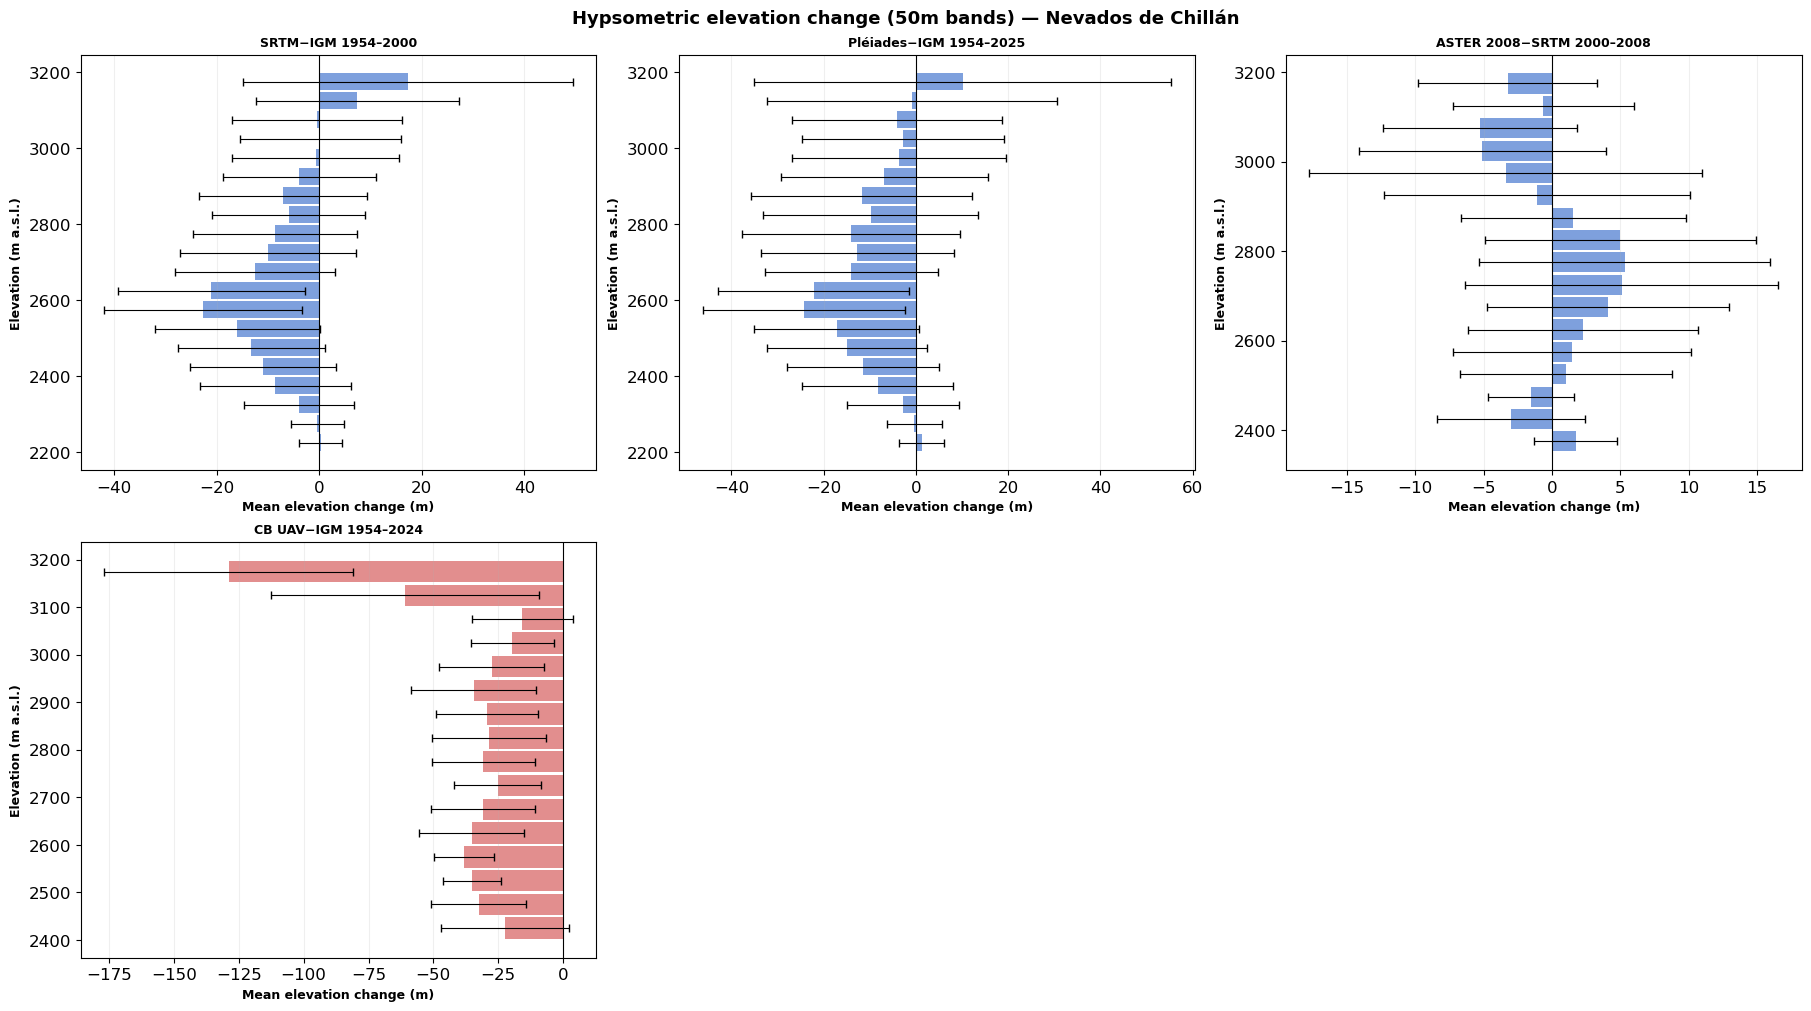

Saved: figures/hypsometric_dh.png


In [9]:
# =============================================================================
print('\n' + '='*70)
print('STEP 3b: Hypsometric elevation change (dH by 50m elevation band)')
print('='*70)

fig_hyps, axes_hyps = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes_hyps = axes_hyps.flatten()
plot_idx = 0

for label, dh_file, shp_key, t_start, t_end, subcomplex in EPOCHS[:6]:
    if plot_idx >= len(axes_hyps):
        break
    dh_path = os.path.join(DH_DIR, dh_file)
    if not os.path.exists(dh_path):
        continue

    outlines = load_outlines(shp_key)
    if shp_key != '1975':
        ids = SUBCOMPLEX_IDS.get(subcomplex, SUBCOMPLEX_IDS['whole'])
        outlines = outlines[outlines['COD_GLA'].isin(ids)]

    try:
        with rasterio.open(dh_path) as dh_src, rasterio.open(SRTM_PATH) as srtm_src:
            proj = outlines[outlines.geometry.notna()].to_crs(dh_src.crs)
            geoms = [mapping(g) for g in proj.geometry]
            dh_m, _ = mask(dh_src, geoms, crop=True, nodata=np.nan, filled=True)
            el_m, _ = mask(srtm_src, geoms, crop=True, nodata=np.nan, filled=True)

            dh_f  = dh_m[0].astype(float).flatten()
            el_f  = el_m[0].astype(float).flatten()
            dh_f[np.abs(dh_f) > 200] = np.nan
            el_f[el_f < 0] = np.nan

            valid = np.isfinite(dh_f) & np.isfinite(el_f)
            dh_v, el_v = dh_f[valid], el_f[valid]
    except Exception:
        continue

    if len(dh_v) < 20:
        continue

    # Bin by 50m elevation bands
    elev_min = int(np.floor(el_v.min() / 50) * 50)
    elev_max = int(np.ceil(el_v.max()  / 50) * 50)
    bins     = np.arange(elev_min, elev_max + 50, 50)
    bin_idx  = np.digitize(el_v, bins)

    band_mids, band_means, band_stds, band_ns = [], [], [], []
    for b in range(1, len(bins)):
        sel = dh_v[bin_idx == b]
        if len(sel) >= 3:
            band_mids.append((bins[b-1] + bins[b]) / 2)
            band_means.append(np.nanmean(sel))
            band_stds.append(np.nanstd(sel))
            band_ns.append(len(sel))

    ax = axes_hyps[plot_idx]
    ax.barh(band_mids, band_means,
            height=45, color=SUBCOMPLEX_COLORS.get(subcomplex, '#4878CF'),
            alpha=0.7, xerr=band_stds, error_kw={'linewidth':0.8, 'capsize':3})
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean elevation change (m)', fontsize=9)
    ax.set_ylabel('Elevation (m a.s.l.)', fontsize=9)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='x')
    plot_idx += 1

for j in range(plot_idx, len(axes_hyps)):
    axes_hyps[j].set_visible(False)

fig_hyps.suptitle('Hypsometric elevation change (50m bands) — Nevados de Chillán',
                  fontsize=13, fontweight='bold')
fig_hyps.savefig(os.path.join(FIGURES, 'hypsometric_dh.png'),
                 dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/hypsometric_dh.png')


## Cell 10 — Step 4: Spatial autocorrelation (Moran's I)

In [10]:
# =============================================================================
print('\n' + '='*70)
print("STEP 4: Spatial autocorrelation — Global Moran's I")
print('='*70)

moran_rows = []

for label, dh_file, shp_key, t_start, t_end, subcomplex in EPOCHS:
    dh_path = os.path.join(DH_DIR, dh_file)
    if not os.path.exists(dh_path):
        continue

    outlines = load_outlines(shp_key)
    if shp_key != '1975':
        ids = SUBCOMPLEX_IDS.get(subcomplex, SUBCOMPLEX_IDS['whole'])
        outlines = outlines[outlines['COD_GLA'].isin(ids)]

    try:
        with rasterio.open(dh_path) as src:
            proj  = outlines[outlines.geometry.notna()].to_crs(src.crs)
            geoms = [mapping(g) for g in proj.geometry]
            arr, _ = mask(src, geoms, crop=True, nodata=np.nan, filled=True)
            arr = arr[0].astype(float)
            arr[np.abs(arr) > 200] = np.nan

            # Subsample to max 200×200 for performance
            max_size = 200
            if arr.shape[0] > max_size or arr.shape[1] > max_size:
                step_r = max(1, arr.shape[0] // max_size)
                step_c = max(1, arr.shape[1] // max_size)
                arr = arr[::step_r, ::step_c]

            finite_mask = np.isfinite(arr)
            arr[~finite_mask] = 0.0

            w = lat2W(*arr.shape, rook=True)
            w.transform = 'r'
            moran = Moran(arr.flatten(), w)

        sig = '✓' if moran.p_sim < 0.05 else 'ns'
        print(f'  {label:<32} I={moran.I:.4f}  p={moran.p_sim:.4f}  {sig}')
        moran_rows.append({
            'epoch':    label,
            'moran_I':  round(moran.I, 4),
            'moran_p':  round(moran.p_sim, 4),
            'significant': moran.p_sim < 0.05,
        })
    except Exception as e:
        print(f'  SKIP Moran {label}: {e}')

pd.DataFrame(moran_rows).to_csv(
    os.path.join(RESULTS, 'moran_i_results.csv'), index=False)
print(f'\nSaved: results/moran_i_results.csv')
print('\nHigh Moran\'s I (>0.7) expected: spatially coherent thinning patterns')
print('confirm that elevation loss is driven by systematic processes (climate,')
print('aspect, elevation) rather than random noise.')

print('\n\nAll steps complete.')
print(f'Results saved to: {RESULTS}')
print(f'Figures saved to: {FIGURES}')



STEP 4: Spatial autocorrelation — Global Moran's I
  SRTM−IGM 1954–2000               I=0.9566  p=0.0010  ✓
  Pléiades−IGM 1954–2025           I=0.9571  p=0.0010  ✓
  Pléiades−SRTM 2000–2025          I=0.9174  p=0.0010  ✓
  ASTER 2008−SRTM 2000–2008        I=0.7909  p=0.0010  ✓
  ASTER 2018−SRTM 2000–2018        I=0.8394  p=0.0010  ✓
  CB UAV−IGM 1954–2024             I=0.8774  p=0.0010  ✓
  CB UAV−SRTM 2000–2024            I=0.7233  p=0.0010  ✓
  LT UAV−IGM 1954–2024             I=0.9139  p=0.0010  ✓
  LT UAV−SRTM 2000–2024            I=0.8733  p=0.0010  ✓

Saved: results/moran_i_results.csv

High Moran's I (>0.7) expected: spatially coherent thinning patterns
confirm that elevation loss is driven by systematic processes (climate,
aspect, elevation) rather than random noise.


All steps complete.
Results saved to: /Users/milliespencer/Glacier-DEM-coregistration-and-MB/results
Figures saved to: /Users/milliespencer/Glacier-DEM-coregistration-and-MB/figures


Topographic control weakened significantly over time — from weak-but-significant elevation gradient in long-term epochs to essentially zero topographic control by 2000–2025. This suggests the entire complex is now losing mass uniformly regardless of elevation, indicating the accumulation zones can no longer compensate for ablation.
Area change and elevation change are decoupled (ρ=-0.018, p=0.94) — glaciers retreating in area are not necessarily thinning faster. May reflect volcanic geothermal heating driving basal melt independent of surface area, which is a distinctive feature of this volcanic complex vs non-volcanic Andean glaciers.
Spatial autocorrelation confirms systematic rather than random mass loss — supports attribution to climate forcing rather than measurement noise.


STEP 5: Local Moran's I (LISA) — spatial clustering

SRTM−IGM 1954–2000
  Significant clusters: 10,545 pixels (14.7%)
  HH (high loss near high loss): 2,987 (4.2%)
  LL (low loss near low loss):   7,479 (10.4%)


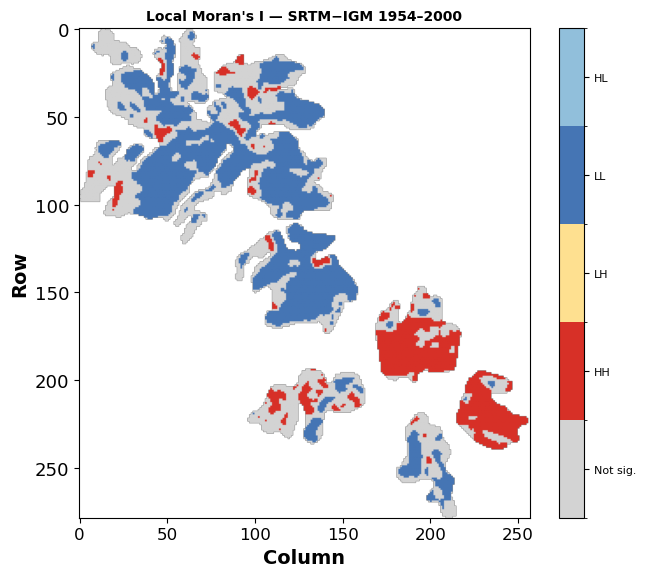


Pléiades−IGM 1954–2025
  Significant clusters: 10,480 pixels (14.6%)
  HH (high loss near high loss): 2,879 (4.0%)
  LL (low loss near low loss):   7,543 (10.5%)


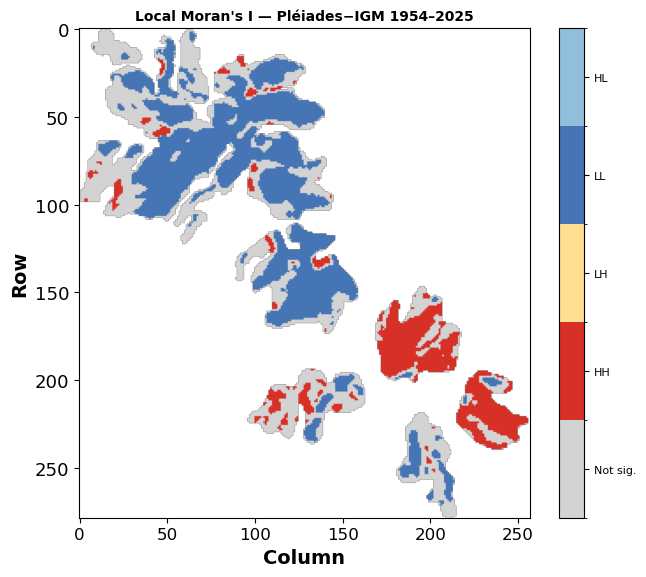


Pléiades−SRTM 2000–2025
  Significant clusters: 58,127 pixels (97.4%)
  HH (high loss near high loss): 55,752 (93.4%)
  LL (low loss near low loss):   2,217 (3.7%)


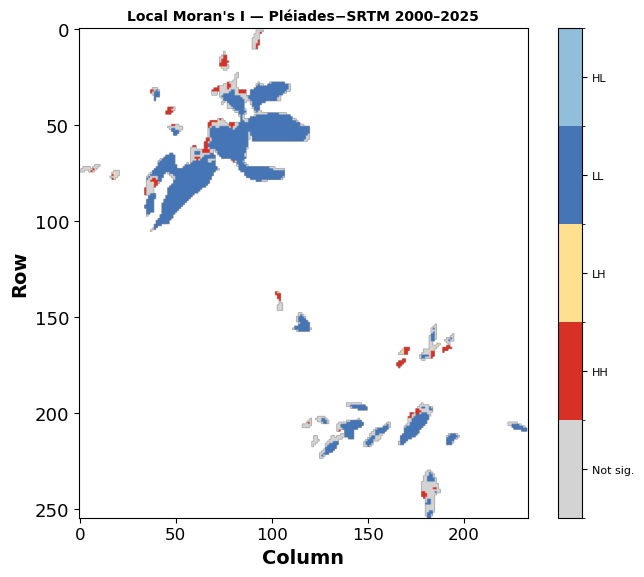


ASTER 2018−SRTM 2000–2018
  Significant clusters: 3,167 pixels (5.3%)
  HH (high loss near high loss): 568 (1.0%)
  LL (low loss near low loss):   2,202 (3.7%)


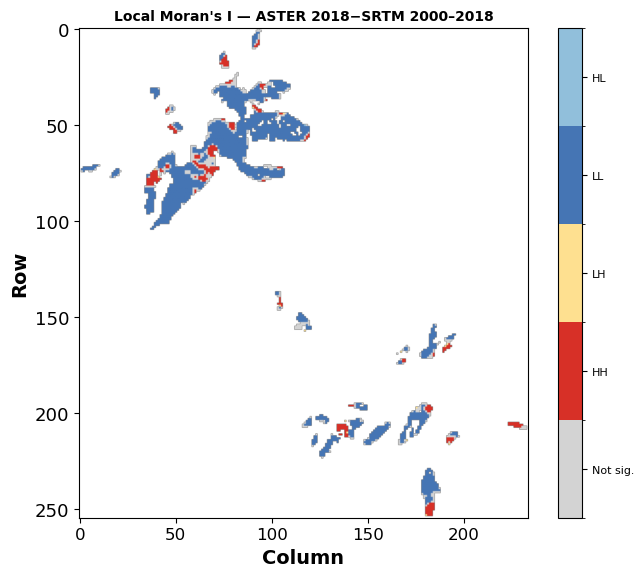


CB UAV−IGM 1954–2024
  Significant clusters: 1,790 pixels (2.5%)
  HH (high loss near high loss): 138 (0.2%)
  LL (low loss near low loss):   1,528 (2.1%)


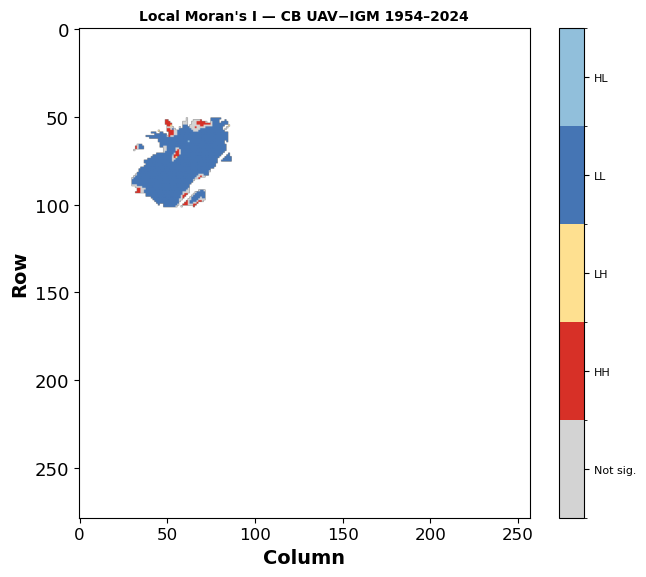


CB UAV−SRTM 2000–2024
  Significant clusters: 793 pixels (6.2%)
  HH (high loss near high loss): 162 (1.3%)
  LL (low loss near low loss):   562 (4.4%)


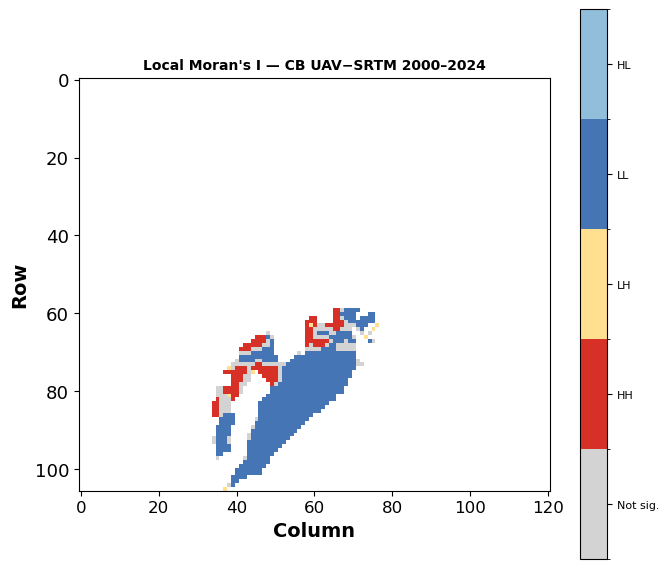


LT UAV−IGM 1954–2024
  Significant clusters: 3,201 pixels (4.4%)
  HH (high loss near high loss): 1,374 (1.9%)
  LL (low loss near low loss):   1,655 (2.3%)


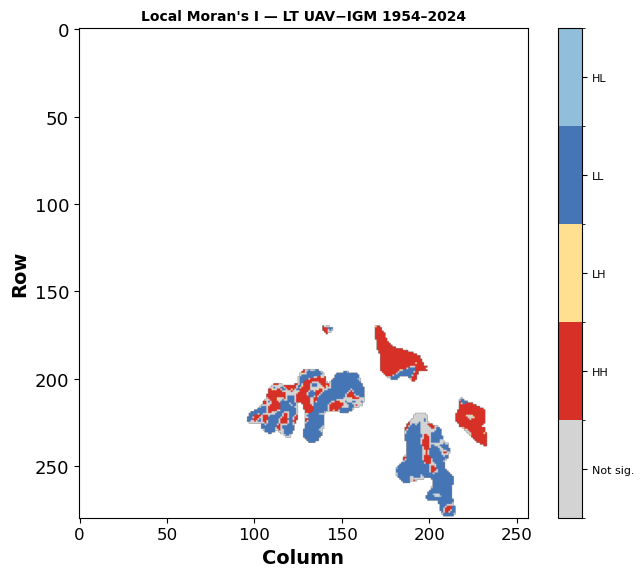


LT UAV−SRTM 2000–2024
  Significant clusters: 553 pixels (4.6%)
  HH (high loss near high loss): 39 (0.3%)
  LL (low loss near low loss):   450 (3.7%)


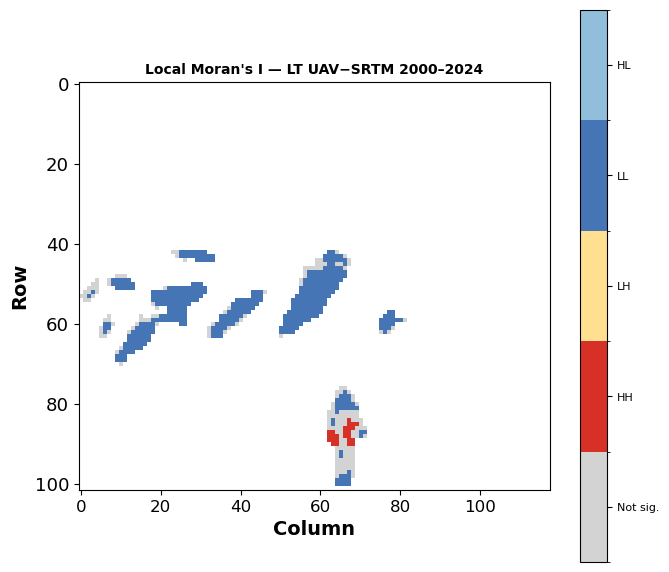


Saved: results/lisa_results.csv


In [14]:
# ==============================================================================
# CELL 11 — Step 5: Local Moran's I (LISA) — spatial clustering of elevation change
# ==============================================================================
print('\n' + '='*70)
print("STEP 5: Local Moran's I (LISA) — spatial clustering")
print('='*70)

def load_outlines(shp_key):
    """Load glacier outlines from SHP dict, reproject to EPSG:32719."""
    gdf = gpd.read_file(SHP[shp_key])
    if shp_key == '1975':
        gdf = gdf.reset_index(drop=True)
        gdf['COD_GLA'] = gdf.index.astype(str) + '_1975'
    elif shp_key == '2019':
        gdf['COD_GLA'] = gdf['COD_GLA'].str.rstrip('@')
        gdf = gdf[gdf['COD_GLA'].notna()]
    return gdf.to_crs('EPSG:32719')

from esda.moran import Moran_Local
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Colormap with transparent NaN
cmap_lisa = mcolors.ListedColormap(
    ['lightgrey', '#d73027', '#fee090', '#4575b4', '#91bfdb'])
cmap_lisa.set_bad(alpha=0)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm   = mcolors.BoundaryNorm(bounds, cmap_lisa.N)

lisa_rows = []

for label, dh_file, shp_key, t_start, t_end, subcomplex in EPOCHS:
    dh_path = os.path.join(DH_DIR, dh_file)
    if not os.path.exists(dh_path):
        continue

    outlines = load_outlines(shp_key)
    if shp_key != '1975':
        ids      = SUBCOMPLEX_IDS.get(subcomplex, SUBCOMPLEX_IDS['whole'])
        outlines = outlines[outlines['COD_GLA'].isin(ids)]

    try:
        with rasterio.open(dh_path) as src:
            proj  = outlines[outlines.geometry.notna()].to_crs(src.crs)
            geoms = [mapping(g) for g in proj.geometry]
            arr, _ = mask(src, geoms, crop=True, nodata=np.nan, filled=True)
            arr    = arr[0].astype(float)
            arr[np.abs(arr) > 200] = np.nan

            # Subsample for performance
            max_size = 150
            if arr.shape[0] > max_size or arr.shape[1] > max_size:
                step_r = max(1, arr.shape[0] // max_size)
                step_c = max(1, arr.shape[1] // max_size)
                arr    = arr[::step_r, ::step_c]

            finite_mask = np.isfinite(arr)
            arr[~finite_mask] = 0.0

            w           = lat2W(*arr.shape, rook=True)
            w.transform = 'r'

            lisa = Moran_Local(arr.flatten(), w, permutations=499, seed=42)

            # Classify: 1=HH, 2=LH, 3=LL, 4=HL, 0=not significant
            sig        = lisa.p_sim < 0.05
            labels_arr = np.zeros(len(lisa.q))
            labels_arr[sig] = lisa.q[sig]

            # Mask non-glacier pixels (originally NaN) back to NaN for display
            labels_2d = labels_arr.reshape(arr.shape).astype(float)
            labels_2d[~finite_mask] = np.nan

            n_hh  = np.sum(labels_arr == 1)
            n_ll  = np.sum(labels_arr == 3)
            n_sig = np.sum(sig)
            pct_sig = n_sig / arr.size * 100

            print(f'\n{label}')
            print(f'  Significant clusters: {n_sig:,} pixels ({pct_sig:.1f}%)')
            print(f'  HH (high loss near high loss): {n_hh:,} ({n_hh/arr.size*100:.1f}%)')
            print(f'  LL (low loss near low loss):   {n_ll:,} ({n_ll/arr.size*100:.1f}%)')

            # Plot LISA map
            fig, ax = plt.subplots(figsize=(7, 6))
            im = ax.imshow(labels_2d, cmap=cmap_lisa, norm=norm, origin='upper')
            cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4])
            cbar.ax.set_yticklabels(
                ['Not sig.', 'HH', 'LH', 'LL', 'HL'], fontsize=8)
            ax.set_title(f"Local Moran's I — {label}",
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('Column')
            ax.set_ylabel('Row')
            fig.tight_layout()
            fig.savefig(
                os.path.join(FIGURES,
                             f'lisa_{label.replace(" ","_").replace("−","minus")}.png'),
                dpi=150, bbox_inches='tight')
            plt.show()
            plt.close(fig)

            lisa_rows.append({
                'epoch':    label,
                'n_sig_px': int(n_sig),
                'pct_sig':  round(pct_sig, 1),
                'n_HH':     int(n_hh),
                'n_LL':     int(n_ll),
            })

    except Exception as e:
        print(f'  SKIP LISA {label}: {e}')

pd.DataFrame(lisa_rows).to_csv(
    os.path.join(RESULTS, 'lisa_results.csv'), index=False)
print(f'\nSaved: results/lisa_results.csv')

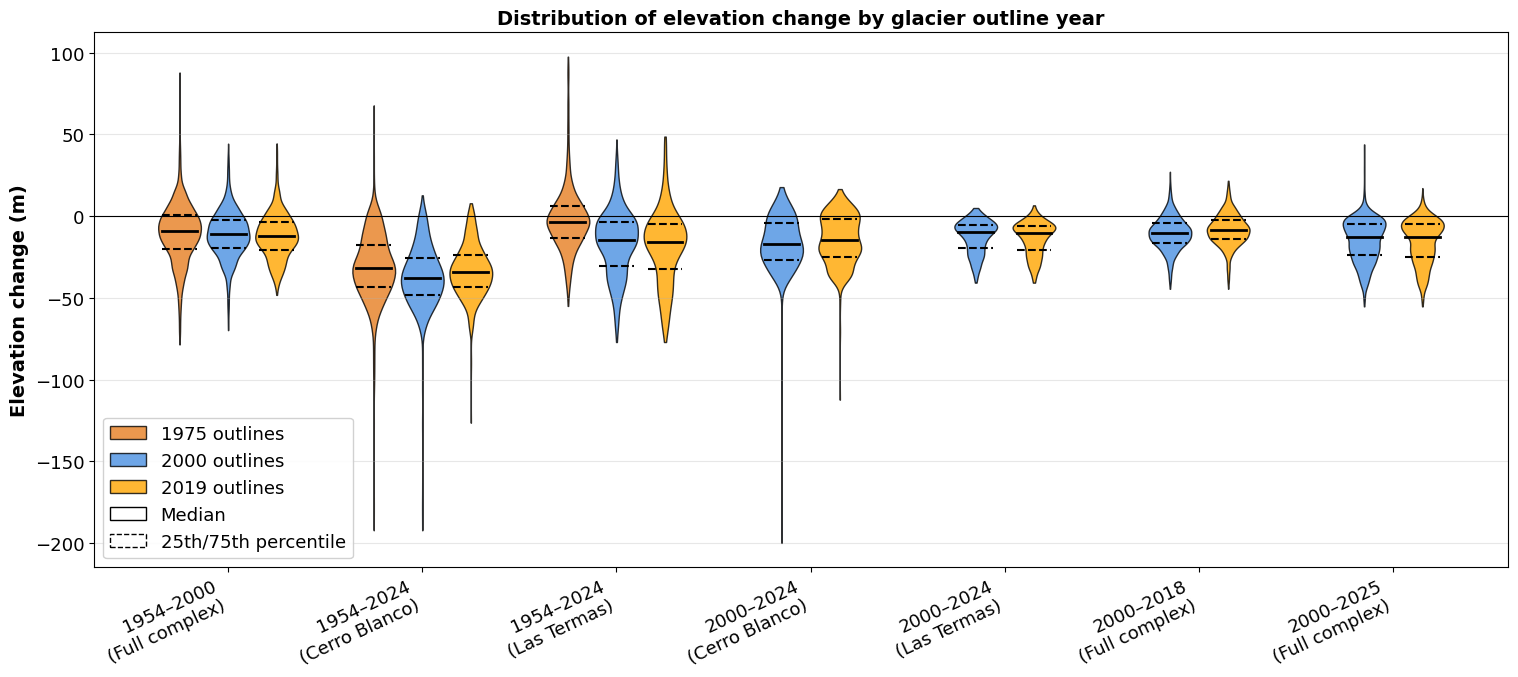

Saved: fig04a_violin_dH.png


In [9]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from shapely.geometry import mapping
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':         14,
    'axes.titlesize':    14,
    'axes.labelsize':    14,
    'xtick.labelsize':   13,
    'ytick.labelsize':   13,
    'legend.fontsize':   13,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

# Load outlines using SHP dict from notebook
gdf_1975 = gpd.read_file(SHP['1975']).reset_index(drop=True)
gdf_1975['COD_GLA'] = gdf_1975.index.astype(str) + '_1975'
gdf_2000 = gpd.read_file(SHP['2000'])
gdf_2019 = gpd.read_file(SHP['2019'])
gdf_2019['COD_GLA'] = gdf_2019['COD_GLA'].str.rstrip('@')

# Epochs: IGM-based epochs compare all three outlines;
# SRTM-based compare 2000 and 2019 only
VIOLIN_EPOCHS = [
    ('SRTM_2000_minus_IGM_1954',         '1954–2000\n(Full complex)',  ['1975','2000','2019']),
    ('CerroBlanco_2024_minus_IGM_1954',   '1954–2024\n(Cerro Blanco)', ['1975','2000','2019']),
    ('LasTermas_2024_minus_IGM_1954',     '1954–2024\n(Las Termas)',   ['1975','2000','2019']),
    ('CerroBlanco_2024_minus_SRTM_2000',  '2000–2024\n(Cerro Blanco)',['2000','2019']),
    ('LasTermas_2024_minus_SRTM_2000',    '2000–2024\n(Las Termas)',  ['2000','2019']),
    ('ASTER_20180301_minus_SRTM_2000',    '2000–2018\n(Full complex)', ['2000','2019']),
    ('Pleiades_2025_minus_SRTM_2000',     '2000–2025\n(Full complex)', ['2000','2019']),
]

OUTLINE_GDFS = {'1975': gdf_1975, '2000': gdf_2000, '2019': gdf_2019}
COLORS       = {'1975': '#E67E22', '2000': '#4A90E2', '2019': '#FFA500'}
OFFSETS_3    = {'1975': -0.25, '2000': 0.0,   '2019':  0.25}
OFFSETS_2    = {              '2000': -0.15,  '2019':  0.15}


def extract_pixels(dh_path, gdf):
    if not os.path.exists(dh_path):
        print(f'  Missing: {os.path.basename(dh_path)}')
        return np.array([])
    with rasterio.open(dh_path) as src:
        gdf_proj = gdf.to_crs(src.crs)
    geoms = [mapping(g) for g in gdf_proj.geometry
             if g is not None and not g.is_empty]
    if not geoms:
        return np.array([])
    try:
        with rasterio.open(dh_path) as src:
            out, _ = rio_mask(src, geoms, crop=True)
            arr = out[0].astype(float)
            if src.nodata is not None:
                arr[arr == src.nodata] = np.nan
        arr[np.abs(arr) > 200] = np.nan
        return arr[np.isfinite(arr)].flatten()
    except Exception as e:
        print(f'  SKIP {os.path.basename(dh_path)}: {e}')
        return np.array([])


# Extract all pixels
records = []
for epoch_key, label, outlines in VIOLIN_EPOCHS:
    dh_path = os.path.join(DH_DIR, f'{epoch_key}_dh.tif')
    for yr in outlines:
        pixels = extract_pixels(dh_path, OUTLINE_GDFS[yr])
        for v in pixels:
            records.append({'epoch': epoch_key, 'label': label,
                            'outline': yr, 'dH': v})

df = pd.DataFrame(records)

# Plot
n   = len(VIOLIN_EPOCHS)
fig, ax = plt.subplots(figsize=(max(14, n * 2.2), 7))

for i, (epoch_key, label, outlines) in enumerate(VIOLIN_EPOCHS, 1):
    offsets = OFFSETS_3 if len(outlines) == 3 else OFFSETS_2
    for yr in outlines:
        data   = df[(df['epoch'] == epoch_key) &
                    (df['outline'] == yr)]['dH'].dropna()
        if data.empty:
            continue
        offset = offsets[yr]
        parts  = ax.violinplot([data], positions=[i + offset],
                               widths=0.22, showmeans=False, showextrema=False)
        for body in parts['bodies']:
            body.set_facecolor(COLORS[yr])
            body.set_edgecolor('black')
            body.set_alpha(0.8)
        q25, q50, q75 = np.percentile(data, [25, 50, 75])
        for y, ls, lw in [(q25,'--',1.5),(q75,'--',1.5),(q50,'-',2.0)]:
            ax.plot([i+offset-0.09, i+offset+0.09], [y, y],
                    linestyle=ls, color='black', linewidth=lw)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(1, n + 1))
ax.set_xticklabels([e[1] for e in VIOLIN_EPOCHS],
                   rotation=25, ha='right', fontsize=13)
ax.set_ylabel('Elevation change (m)', fontsize=14, fontweight='bold')
ax.set_title('Distribution of elevation change by glacier outline year',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

legend_elements = [
    Patch(facecolor=COLORS['1975'], edgecolor='black', alpha=0.8, label='1975 outlines'),
    Patch(facecolor=COLORS['2000'], edgecolor='black', alpha=0.8, label='2000 outlines'),
    Patch(facecolor=COLORS['2019'], edgecolor='black', alpha=0.8, label='2019 outlines'),
    Patch(facecolor='none', edgecolor='black', linestyle='-',  label='Median'),
    Patch(facecolor='none', edgecolor='black', linestyle='--', label='25th/75th percentile'),
]
ax.legend(handles=legend_elements, loc='lower left', framealpha=0.9)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig04a_violin_dH.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig04a_violin_dH.png')

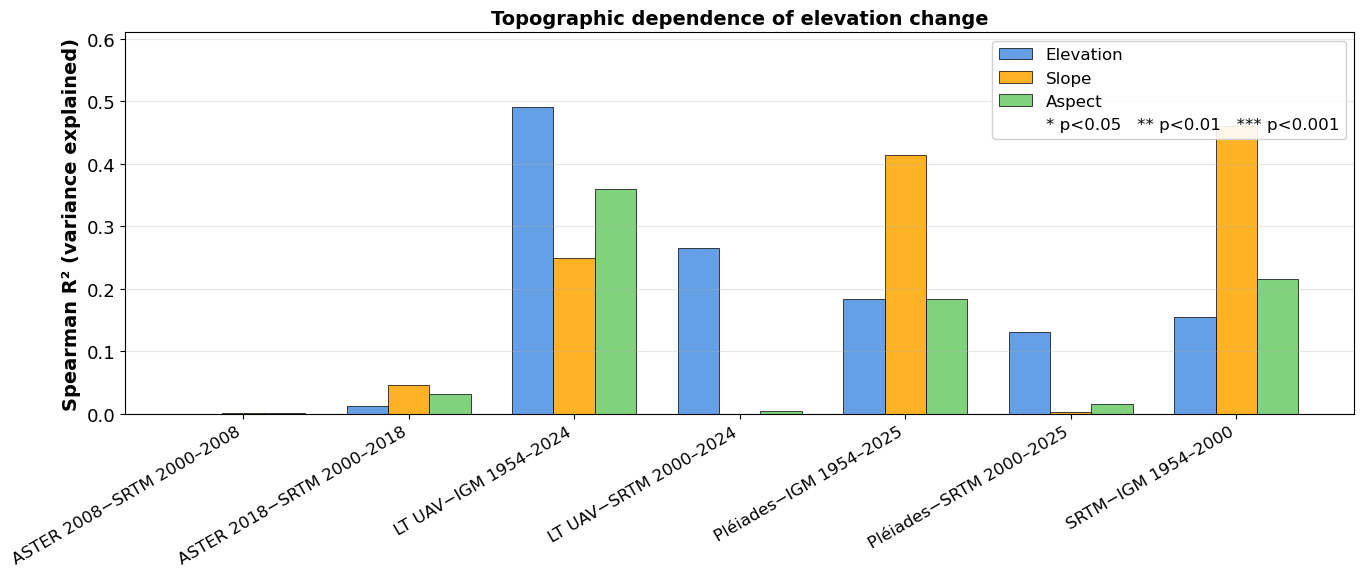

Saved: fig04b_topo_dependence.png


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':         14,
    'axes.titlesize':    14,
    'axes.labelsize':    14,
    'xtick.labelsize':   12,
    'ytick.labelsize':   13,
    'legend.fontsize':   12,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

csv_path = os.path.join(RESULTS, 'topo_correlation_results.csv')
df       = pd.read_csv(csv_path)

# Use Spearman r² and p (primary statistic in our pipeline)
df_r2 = df.pivot_table(index='epoch', columns='topo_var',
                        values='spearman_r2', aggfunc='first')
df_p  = df.pivot_table(index='epoch', columns='topo_var',
                        values='spearman_p',  aggfunc='first')

# Rename topo_var values to friendly labels
topo_rename = {
    'elev_mean_m':  'Elevation',
    'slope_mean':   'Slope',
    'aspect_mean':  'Aspect',
}
df_r2.columns = [topo_rename.get(c, c) for c in df_r2.columns]
df_p.columns  = [topo_rename.get(c, c) for c in df_p.columns]

# Filter to whole-complex rows only (or keep all subcomplexes)
df_r2 = df_r2.dropna(how='all')
df_p  = df_p.dropna(how='all')

topo_vars = ['Elevation', 'Slope', 'Aspect']
colors    = ['#4A90E2', '#FFA500', '#6ACC65']
x         = np.arange(len(df_r2))
width     = 0.25

fig, ax = plt.subplots(figsize=(max(14, len(df_r2) * 1.8), 6))

for j, (var, col) in enumerate(zip(topo_vars, colors)):
    if var not in df_r2.columns:
        continue
    vals = df_r2[var].fillna(0)
    ax.bar(x + (j - 1) * width, vals, width,
           label=var, color=col, alpha=0.85,
           edgecolor='black', linewidth=0.6)

    def sig_star(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        return ''

    if var in df_p.columns:
        for i, (r2_val, p_val) in enumerate(zip(vals, df_p[var].fillna(1))):
            star = sig_star(float(p_val))
            if star:
                ax.text(x[i] + (j - 1) * width, float(r2_val) + 0.005,
                        star, ha='center', va='bottom',
                        fontsize=11, color='red', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_r2.index, rotation=30, ha='right', fontsize=12)
ax.set_ylabel('Spearman R² (variance explained)', fontsize=14, fontweight='bold')
ax.set_title('Topographic dependence of elevation change',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, min(float(df_r2.values.max()) + 0.12, 1.0))
ax.grid(axis='y', alpha=0.3)

handles, labels_ = ax.get_legend_handles_labels()
sig_patch = Patch(facecolor='none', edgecolor='none',
                  label='* p<0.05   ** p<0.01   *** p<0.001')
handles.append(sig_patch)
ax.legend(handles=handles, loc='upper right', framealpha=0.9)

fig.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig04b_topo_dependence.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig04b_topo_dependence.png')

In [7]:
import pandas as pd
df = pd.read_csv(csv_path)
print(df.columns.tolist())
print(df.head(3))

['epoch', 't_start', 't_end', 'subcomplex', 'topo_var', 'n_glaciers', 'n', 'pearson_r', 'pearson_r2', 'pearson_p', 'spearman_r', 'spearman_r2', 'spearman_p']
                epoch  t_start  t_end subcomplex     topo_var  n_glaciers  n  \
0  SRTM−IGM 1954–2000     1954   2000      whole  elev_mean_m           7  7   
1  SRTM−IGM 1954–2000     1954   2000      whole   slope_mean           7  7   
2  SRTM−IGM 1954–2000     1954   2000      whole  aspect_mean           7  7   

   pearson_r  pearson_r2  pearson_p  spearman_r  spearman_r2  spearman_p  
0   0.502502    0.252509   0.250418    0.392857     0.154337    0.383317  
1   0.701391    0.491950   0.079059    0.678571     0.460459    0.093750  
2  -0.498598    0.248600   0.254718   -0.464286     0.215561    0.293934  


In [11]:
print(df[['epoch','subcomplex','topo_var','n_glaciers','spearman_r2','spearman_p']]
      .sort_values('spearman_p').head(20))

                        epoch  subcomplex     topo_var  n_glaciers  \
6     Pléiades−SRTM 2000–2025       whole  elev_mean_m          28   
1          SRTM−IGM 1954–2000       whole   slope_mean           7   
4      Pléiades−IGM 1954–2025       whole   slope_mean           7   
18      LT UAV−SRTM 2000–2024  las_termas  elev_mean_m          10   
15       LT UAV−IGM 1954–2024  las_termas  elev_mean_m           5   
13  ASTER 2018−SRTM 2000–2018       whole   slope_mean          28   
17       LT UAV−IGM 1954–2024  las_termas  aspect_mean           5   
2          SRTM−IGM 1954–2000       whole  aspect_mean           7   
3      Pléiades−IGM 1954–2025       whole  elev_mean_m           7   
5      Pléiades−IGM 1954–2025       whole  aspect_mean           7   
14  ASTER 2018−SRTM 2000–2018       whole  aspect_mean          28   
0          SRTM−IGM 1954–2000       whole  elev_mean_m           7   
16       LT UAV−IGM 1954–2024  las_termas   slope_mean           5   
8     Pléiades−SRTM 